# DESI DR1 browser-representation evidence

This notebook creates the figures and metrics required before building a research poster. It compares observed DESI DR1 LSS rows with the current GPU display policy and two deterministic comparator policies.

**Scientific boundary:** it is a browser-representation validation. It does not estimate clustering, a density field, completeness correction, or physical voids.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

repository_url = 'https://github.com/Biswajit1999/NASADIYA-LIGHTCONE.git'
repository_dir = Path('/content/NASADIYA-LIGHTCONE')
if not repository_dir.exists():
    subprocess.run(['git', 'clone', '--depth', '1', repository_url, str(repository_dir)], check=True)
os.chdir(repository_dir)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print('Repository ready:', Path.cwd())

Repository ready: /content/NASADIYA-LIGHTCONE


## Select the local Parquet source

Set `USE_GOOGLE_DRIVE = True` when the 194 MB bundle is stored in Drive. Set it to `False` to upload the file from your computer. Update the Drive path if needed.

In [2]:
USE_GOOGLE_DRIVE = False
DRIVE_PARQUET_PATH = '/content/drive/MyDrive/desi_dr1_lss_research_bundle.parquet'

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = Path(DRIVE_PARQUET_PATH)
else:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = Path('/content') / next(iter(uploaded))

MANIFEST_PATH = Path('data/processed/desi-dr1/full-cloud/full-cloud.json')
assert DATA_PATH.exists(), f'Missing Parquet input: {DATA_PATH}'
assert MANIFEST_PATH.exists(), f'Missing full-cloud manifest: {MANIFEST_PATH}'
print('Input:', DATA_PATH)
print('Manifest:', MANIFEST_PATH)

Saving desi_dr1_lss_research_bundle.parquet to desi_dr1_lss_research_bundle.parquet


AssertionError: Missing Parquet input: /content/desi_dr1_lss_research_bundle.parquet

In [3]:
from pathlib import Path
import os

# Find the cloned repository regardless of the current working directory.
repo_candidates = [Path.cwd(), Path("/content/NASADIYA-LIGHTCONE")]
REPO = next(
    (path for path in repo_candidates
     if (path / "scripts" / "build_desi_publication_figures.py").exists()),
    None,
)

assert REPO is not None, "NASADIYA-LIGHTCONE repository was not found."
os.chdir(REPO)

# Recover the Parquet file that was just uploaded.
parquet_candidates = sorted(
    [path for path in Path("/content").rglob("*.parquet") if path.stat().st_size > 100_000_000],
    key=lambda path: path.stat().st_size,
    reverse=True,
)

assert parquet_candidates, "No large Parquet file was found under /content."

DATA_PATH = parquet_candidates[0]
MANIFEST_PATH = REPO / "data" / "processed" / "desi-dr1" / "full-cloud" / "full-cloud.json"

assert DATA_PATH.exists(), f"Missing Parquet input: {DATA_PATH}"
assert MANIFEST_PATH.exists(), f"Missing GPU manifest: {MANIFEST_PATH}"

print("Repository :", REPO)
print("Parquet    :", DATA_PATH)
print("Size [MB]  :", round(DATA_PATH.stat().st_size / 1024**2, 2))
print("Manifest   :", MANIFEST_PATH)

Repository : /content/NASADIYA-LIGHTCONE
Parquet    : /content/NASADIYA-LIGHTCONE/desi_dr1_lss_research_bundle.parquet
Size [MB]  : 185.12
Manifest   : /content/NASADIYA-LIGHTCONE/data/processed/desi-dr1/full-cloud/full-cloud.json


In [4]:
from pathlib import Path
import subprocess
import sys

evidence_dir = REPO / "figures" / "publication_evidence"

command = [
    sys.executable,
    "scripts/build_desi_publication_figures.py",
    "--input", str(DATA_PATH),
    "--full-cloud-manifest", str(MANIFEST_PATH),
    "--output-dir", str(evidence_dir),
    "--budgets", "125000,250000,500000,1000000",
    "--poster-budget", "125000",
    "--dpi", "300",
]

subprocess.run(command, check=True)
print("Evidence figures written to:", evidence_dir)

Evidence figures written to: /content/NASADIYA-LIGHTCONE/figures/publication_evidence


In [5]:
import sys
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

sys.path.insert(0, str(REPO / "pipeline"))
sys.path.insert(0, str(REPO / "scripts"))

from assess_desi_common import load_parent
from fidelity_grid import equal_area_sky_cells, cartesian_voxel_cells, occupancy_metrics
from fidelity_helpers import scalar_metrics, categorical_table
from desi_strata import redshift_bin_labels
from nasadiya_lightcone.sampling import (
    select_gpu_golden_ratio_index,
    select_stratified_lowest_hash,
)

audit_dir = REPO / "figures" / "journal_audit"
audit_dir.mkdir(parents=True, exist_ok=True)

TRACERS = ["BGS", "LRG", "ELG", "QSO", "UNKNOWN"]
COLORS = {
    "BGS": "#1f9bb6",
    "LRG": "#d87c22",
    "ELG": "#3da96a",
    "QSO": "#7f5bb7",
    "UNKNOWN": "#7f8c8d",
}

# Read the validated catalogue fields used by the browser analysis.
parent = load_parent(DATA_PATH).copy()

# Additional derived quantities.
parent["radius_mpc"] = np.sqrt(
    parent["x_mpc"] ** 2
    + parent["y_mpc"] ** 2
    + parent["z_mpc"] ** 2
)

parent["sky_cell"] = equal_area_sky_cells(
    parent["ra_deg"],
    parent["dec_deg"],
    ra_bins=24,
    sin_dec_bins=12,
)

parent["redshift_bin"] = redshift_bin_labels(
    parent["redshift"],
    z_max=3.6,
    z_bins=48,
)

# ---------------------------
# 1. Catalogue quality audit
# ---------------------------

quality_summary = {
    "input_file": str(DATA_PATH),
    "input_bytes": int(DATA_PATH.stat().st_size),
    "sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "valid_observed_rows": int(len(parent)),
    "duplicate_object_ids": int(parent["object_id"].duplicated().sum()),
    "missing_values": {
        column: int(parent[column].isna().sum())
        for column in parent.columns
    },
    "ra_outside_0_360": int(((parent["ra_deg"] < 0) | (parent["ra_deg"] >= 360)).sum()),
    "dec_outside_minus90_90": int(((parent["dec_deg"] < -90) | (parent["dec_deg"] > 90)).sum()),
    "negative_redshift_rows": int((parent["redshift"] < 0).sum()),
    "redshift_quantiles": {
        str(q): float(parent["redshift"].quantile(q))
        for q in [0.0, 0.01, 0.05, 0.50, 0.95, 0.99, 1.0]
    },
    "radius_mpc_quantiles": {
        str(q): float(parent["radius_mpc"].quantile(q))
        for q in [0.0, 0.01, 0.05, 0.50, 0.95, 0.99, 1.0]
    },
    "tracer_counts": {
        str(key): int(value)
        for key, value in parent["tracer"].value_counts().sort_index().items()
    },
}

(audit_dir / "catalogue_quality_summary.json").write_text(
    json.dumps(quality_summary, indent=2),
    encoding="utf-8",
)

display(pd.DataFrame([quality_summary["tracer_counts"]]))
print(json.dumps(quality_summary, indent=2)[:3000])

,BGS,ELG,LRG,QSO
0,300017,2432027,2138604,1223170


{
  "input_file": "/content/NASADIYA-LIGHTCONE/desi_dr1_lss_research_bundle.parquet",
  "input_bytes": 194111717,
  "sha256": "aba7c9236e516459e914d079e4b38bf1e75823ef0707e90da066914a5bda942e",
  "valid_observed_rows": 6093818,
  "duplicate_object_ids": 0,
  "missing_values": {
    "object_id": 0,
    "tracer": 0,
    "ra_deg": 0,
    "dec_deg": 0,
    "redshift": 0,
    "x_mpc": 0,
    "y_mpc": 0,
    "z_mpc": 0,
    "radius_mpc": 0,
    "sky_cell": 0,
    "redshift_bin": 0
  },
  "ra_outside_0_360": 0,
  "dec_outside_minus90_90": 0,
  "negative_redshift_rows": 0,
  "redshift_quantiles": {
    "0.0": 0.10003384202718735,
    "0.01": 0.23250775456428527,
    "0.05": 0.4024720087647438,
    "0.5": 0.9974438846111298,
    "0.95": 2.208091366291046,
    "0.99": 2.917587594985962,
    "1.0": 3.499997854232788
  },
  "radius_mpc_quantiles": {
    "0.0": 432.7084655761719,
    "0.01": 972.4762939453125,
    "0.05": 1608.940771484375,
    "0.5": 3389.2772216796875,
    "0.95": 5599.9293457031

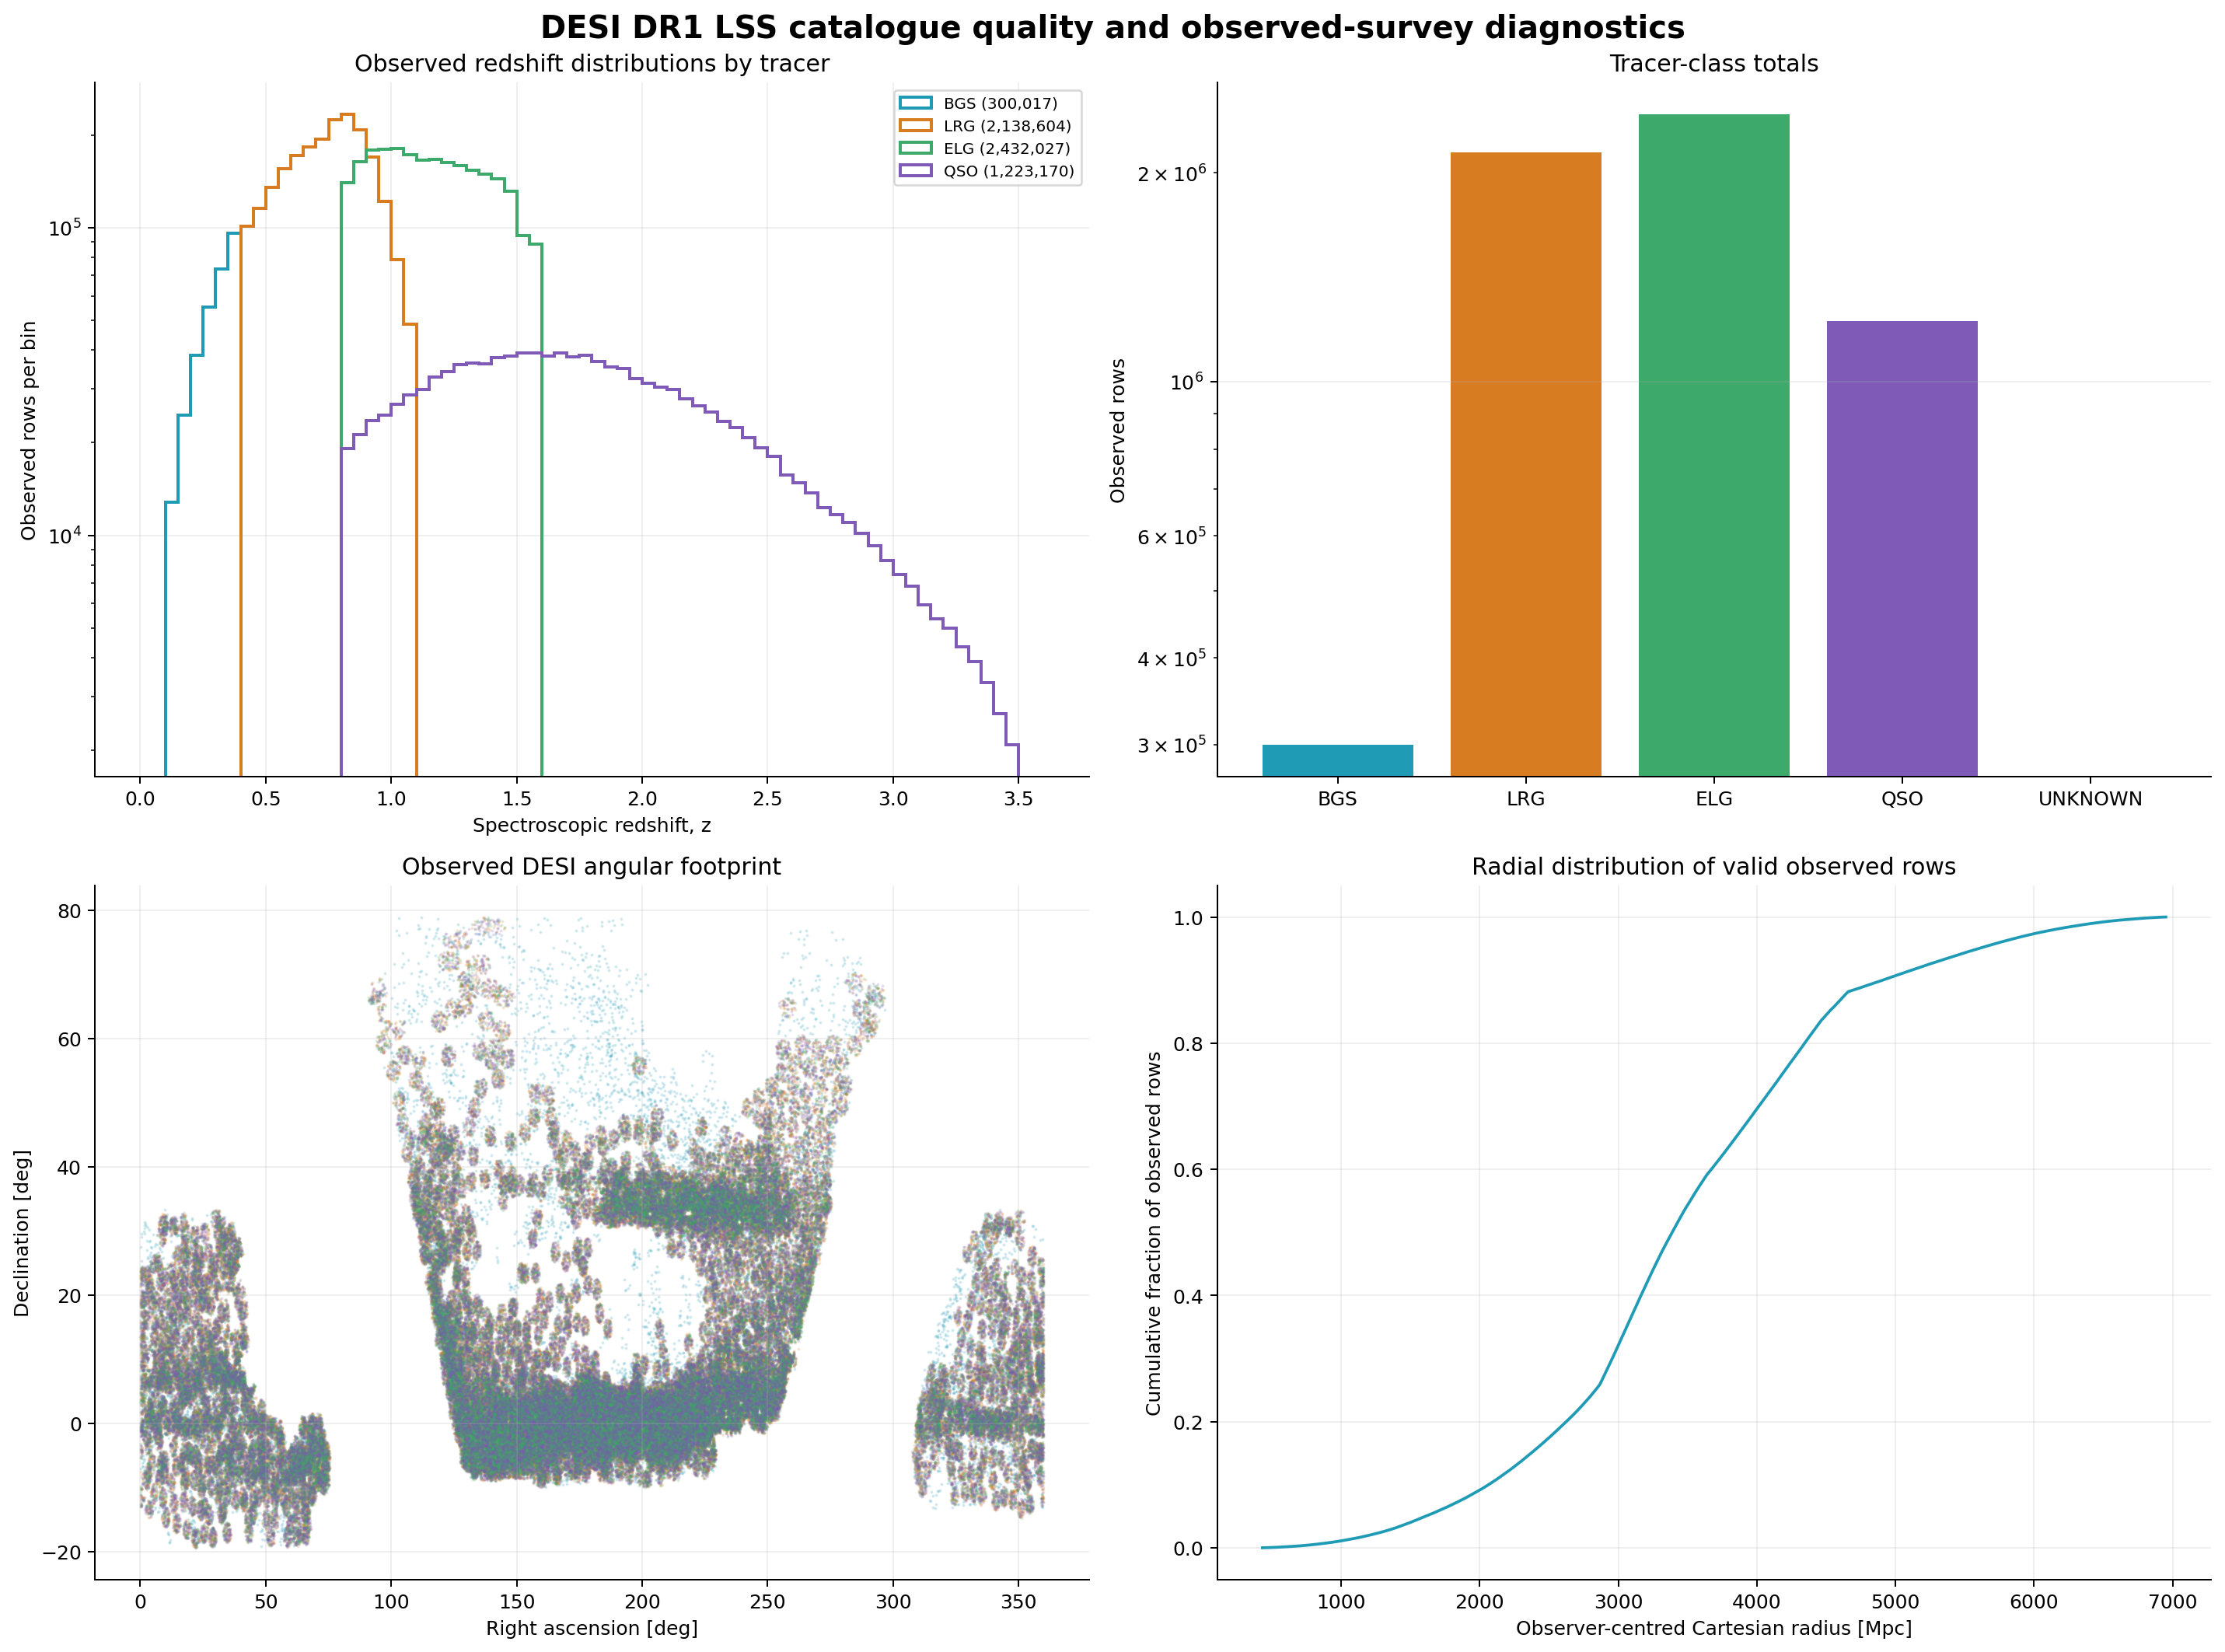

In [6]:
plot_sample = parent.sample(
    n=min(250_000, len(parent)),
    random_state=20260625,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=180)
fig.suptitle(
    "DESI DR1 LSS catalogue quality and observed-survey diagnostics",
    fontsize=16,
    fontweight="bold",
)

# Redshift distributions by tracer
redshift_edges = np.linspace(0.0, 3.6, 73)

for tracer in TRACERS:
    subset = parent.loc[parent["tracer"] == tracer, "redshift"]
    if len(subset):
        axes[0, 0].hist(
            subset,
            bins=redshift_edges,
            histtype="step",
            linewidth=1.6,
            label=f"{tracer} ({len(subset):,})",
            color=COLORS[tracer],
        )

axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Spectroscopic redshift, z")
axes[0, 0].set_ylabel("Observed rows per bin")
axes[0, 0].set_title("Observed redshift distributions by tracer")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.2)

# Tracer totals
counts = parent["tracer"].value_counts().reindex(TRACERS, fill_value=0)

axes[0, 1].bar(
    counts.index,
    counts.values,
    color=[COLORS[label] for label in counts.index],
)

axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("Observed rows")
axes[0, 1].set_title("Tracer-class totals")
axes[0, 1].grid(axis="y", alpha=0.2)

# Observed angular footprint
for tracer in TRACERS:
    subset = plot_sample.loc[plot_sample["tracer"] == tracer]
    if len(subset):
        axes[1, 0].scatter(
            subset["ra_deg"],
            subset["dec_deg"],
            s=0.35,
            alpha=0.18,
            color=COLORS[tracer],
            label=tracer,
            rasterized=True,
        )

axes[1, 0].set_xlabel("Right ascension [deg]")
axes[1, 0].set_ylabel("Declination [deg]")
axes[1, 0].set_title("Observed DESI angular footprint")
axes[1, 0].grid(alpha=0.2)

# Radial cumulative distribution
radius_sorted = np.sort(parent["radius_mpc"].to_numpy())
cdf = np.linspace(0.0, 1.0, len(radius_sorted), endpoint=True)

axes[1, 1].plot(radius_sorted, cdf, color="#1f9bb6", linewidth=1.5)
axes[1, 1].set_xlabel("Observer-centred Cartesian radius [Mpc]")
axes[1, 1].set_ylabel("Cumulative fraction of observed rows")
axes[1, 1].set_title("Radial distribution of valid observed rows")
axes[1, 1].grid(alpha=0.2)

for axis in axes.flat:
    axis.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(audit_dir / "01_catalogue_quality_overview.png", dpi=300)
fig.savefig(audit_dir / "01_catalogue_quality_overview.pdf")
plt.show()

In [7]:
BUDGET = 125_000
RANDOM_REPEATS = 8
VOXEL_SCALES_MPC = [250.0, 500.0, 1000.0]

parent_sky = parent["sky_cell"]
parent_voxels_250 = cartesian_voxel_cells(parent, cell_size_mpc=250.0)
redshift_edges = np.linspace(0.0, 3.6, 49)

gpu_sample = select_gpu_golden_ratio_index(parent, BUDGET)

balanced_sample = select_stratified_lowest_hash(
    parent,
    BUDGET,
    group_columns=("tracer", "sky_cell", "redshift_bin"),
)

def evaluate_representation(sample, label, voxel_size_mpc=250.0):
    fraction = len(sample) / len(parent)

    redshift = scalar_metrics(
        parent["redshift"],
        sample["redshift"],
        bins=redshift_edges,
    )

    tracer_table = categorical_table(
        parent["tracer"],
        sample["tracer"],
        name="tracer",
    )

    sky = occupancy_metrics(
        parent_sky,
        equal_area_sky_cells(
            sample["ra_deg"],
            sample["dec_deg"],
            ra_bins=24,
            sin_dec_bins=12,
        ),
        sampling_fraction=fraction,
    )

    if voxel_size_mpc == 250.0:
        parent_voxels = parent_voxels_250
    else:
        parent_voxels = cartesian_voxel_cells(
            parent,
            cell_size_mpc=voxel_size_mpc,
        )

    voxel = occupancy_metrics(
        parent_voxels,
        cartesian_voxel_cells(
            sample,
            cell_size_mpc=voxel_size_mpc,
        ),
        sampling_fraction=fraction,
    )

    return {
        "policy": label,
        "selected_rows": len(sample),
        "sampling_fraction": fraction,
        "voxel_size_mpc": voxel_size_mpc,
        "redshift_ks": redshift["ks_distance"],
        "redshift_js_bits": redshift["jensen_shannon_divergence_bits"],
        "tracer_tvd": float(
            0.5 * np.abs(tracer_table["fraction_residual"]).sum()
        ),
        "sky_correlation": sky["occupancy_correlation"],
        "sky_nrmse": sky["occupancy_nrmse"],
        "sky_recall": sky["occupied_cell_recall"],
        "voxel_correlation": voxel["occupancy_correlation"],
        "voxel_nrmse": voxel["occupancy_nrmse"],
        "voxel_recall": voxel["occupied_cell_recall"],
    }

policy_rows = [
    evaluate_representation(gpu_sample, "GPU low-discrepancy"),
    evaluate_representation(balanced_sample, "Tracer-sky-redshift balanced"),
]

rng = np.random.default_rng(20260625)

for repeat in range(RANDOM_REPEATS):
    positions = rng.choice(
        len(parent),
        size=BUDGET,
        replace=False,
    )
    random_sample = parent.iloc[positions].copy()

    result = evaluate_representation(
        random_sample,
        f"Random baseline {repeat + 1}",
    )
    result["repeat"] = repeat + 1
    policy_rows.append(result)

policy_metrics = pd.DataFrame(policy_rows)
policy_metrics.to_csv(
    audit_dir / "02_policy_and_random_baseline_metrics.csv",
    index=False,
)

display(policy_metrics.round(7))

,policy,selected_rows,sampling_fraction,voxel_size_mpc,redshift_ks,redshift_js_bits,tracer_tvd,sky_correlation,sky_nrmse,sky_recall,voxel_correlation,voxel_nrmse,voxel_recall,repeat
0,GPU low-discrepancy,125001,0.020513,250.0,0.001185,0.000022,0.000062,0.999946,0.007505,0.977444,0.984242,0.162496,0.595644,NaN
1,Tracer-sky-redshift balanced,125000,0.020513,250.0,0.001393,0.000002,0.000284,0.999996,0.002130,0.954887,0.978769,0.189532,0.581878,NaN
2,Random baseline 1,125000,0.020513,250.0,0.002133,0.000063,0.001962,0.999553,0.022285,0.962406,0.975225,0.206418,0.581022,1.0
3,Random baseline 2,125000,0.020513,250.0,0.002782,0.000085,0.002365,0.999499,0.022915,0.977444,0.975500,0.204001,0.580337,2.0
4,Random baseline 3,125000,0.020513,250.0,0.002618,0.000047,0.000756,0.999542,0.021786,0.977444,0.975416,0.204485,0.579960,3.0
5,Random baseline 4,125000,0.020513,250.0,0.001828,0.000042,0.001833,0.999519,0.022317,0.969925,0.975785,0.203035,0.579207,4.0
6,Random baseline 5,125000,0.020513,250.0,0.002056,0.000066,0.001046,0.999562,0.021268,0.984962,0.974776,0.206915,0.577563,5.0
7,Random baseline 6,125000,0.020513,250.0,0.001367,0.000061,0.001023,0.999595,0.020534,0.962406,0.975032,0.206174,0.582666,6.0
8,Random baseline 7,125000,0.020513,250.0,0.002880,0.000062,0.001786,0.999299,0.026888,0.977444,0.974921,0.206037,0.579652,7.0
9,Random baseline 8,125000,0.020513,250.0,0.002852,0.000061,0.002078,0.999515,0.022917,0.977444,0.974873,0.206327,0.578043,8.0


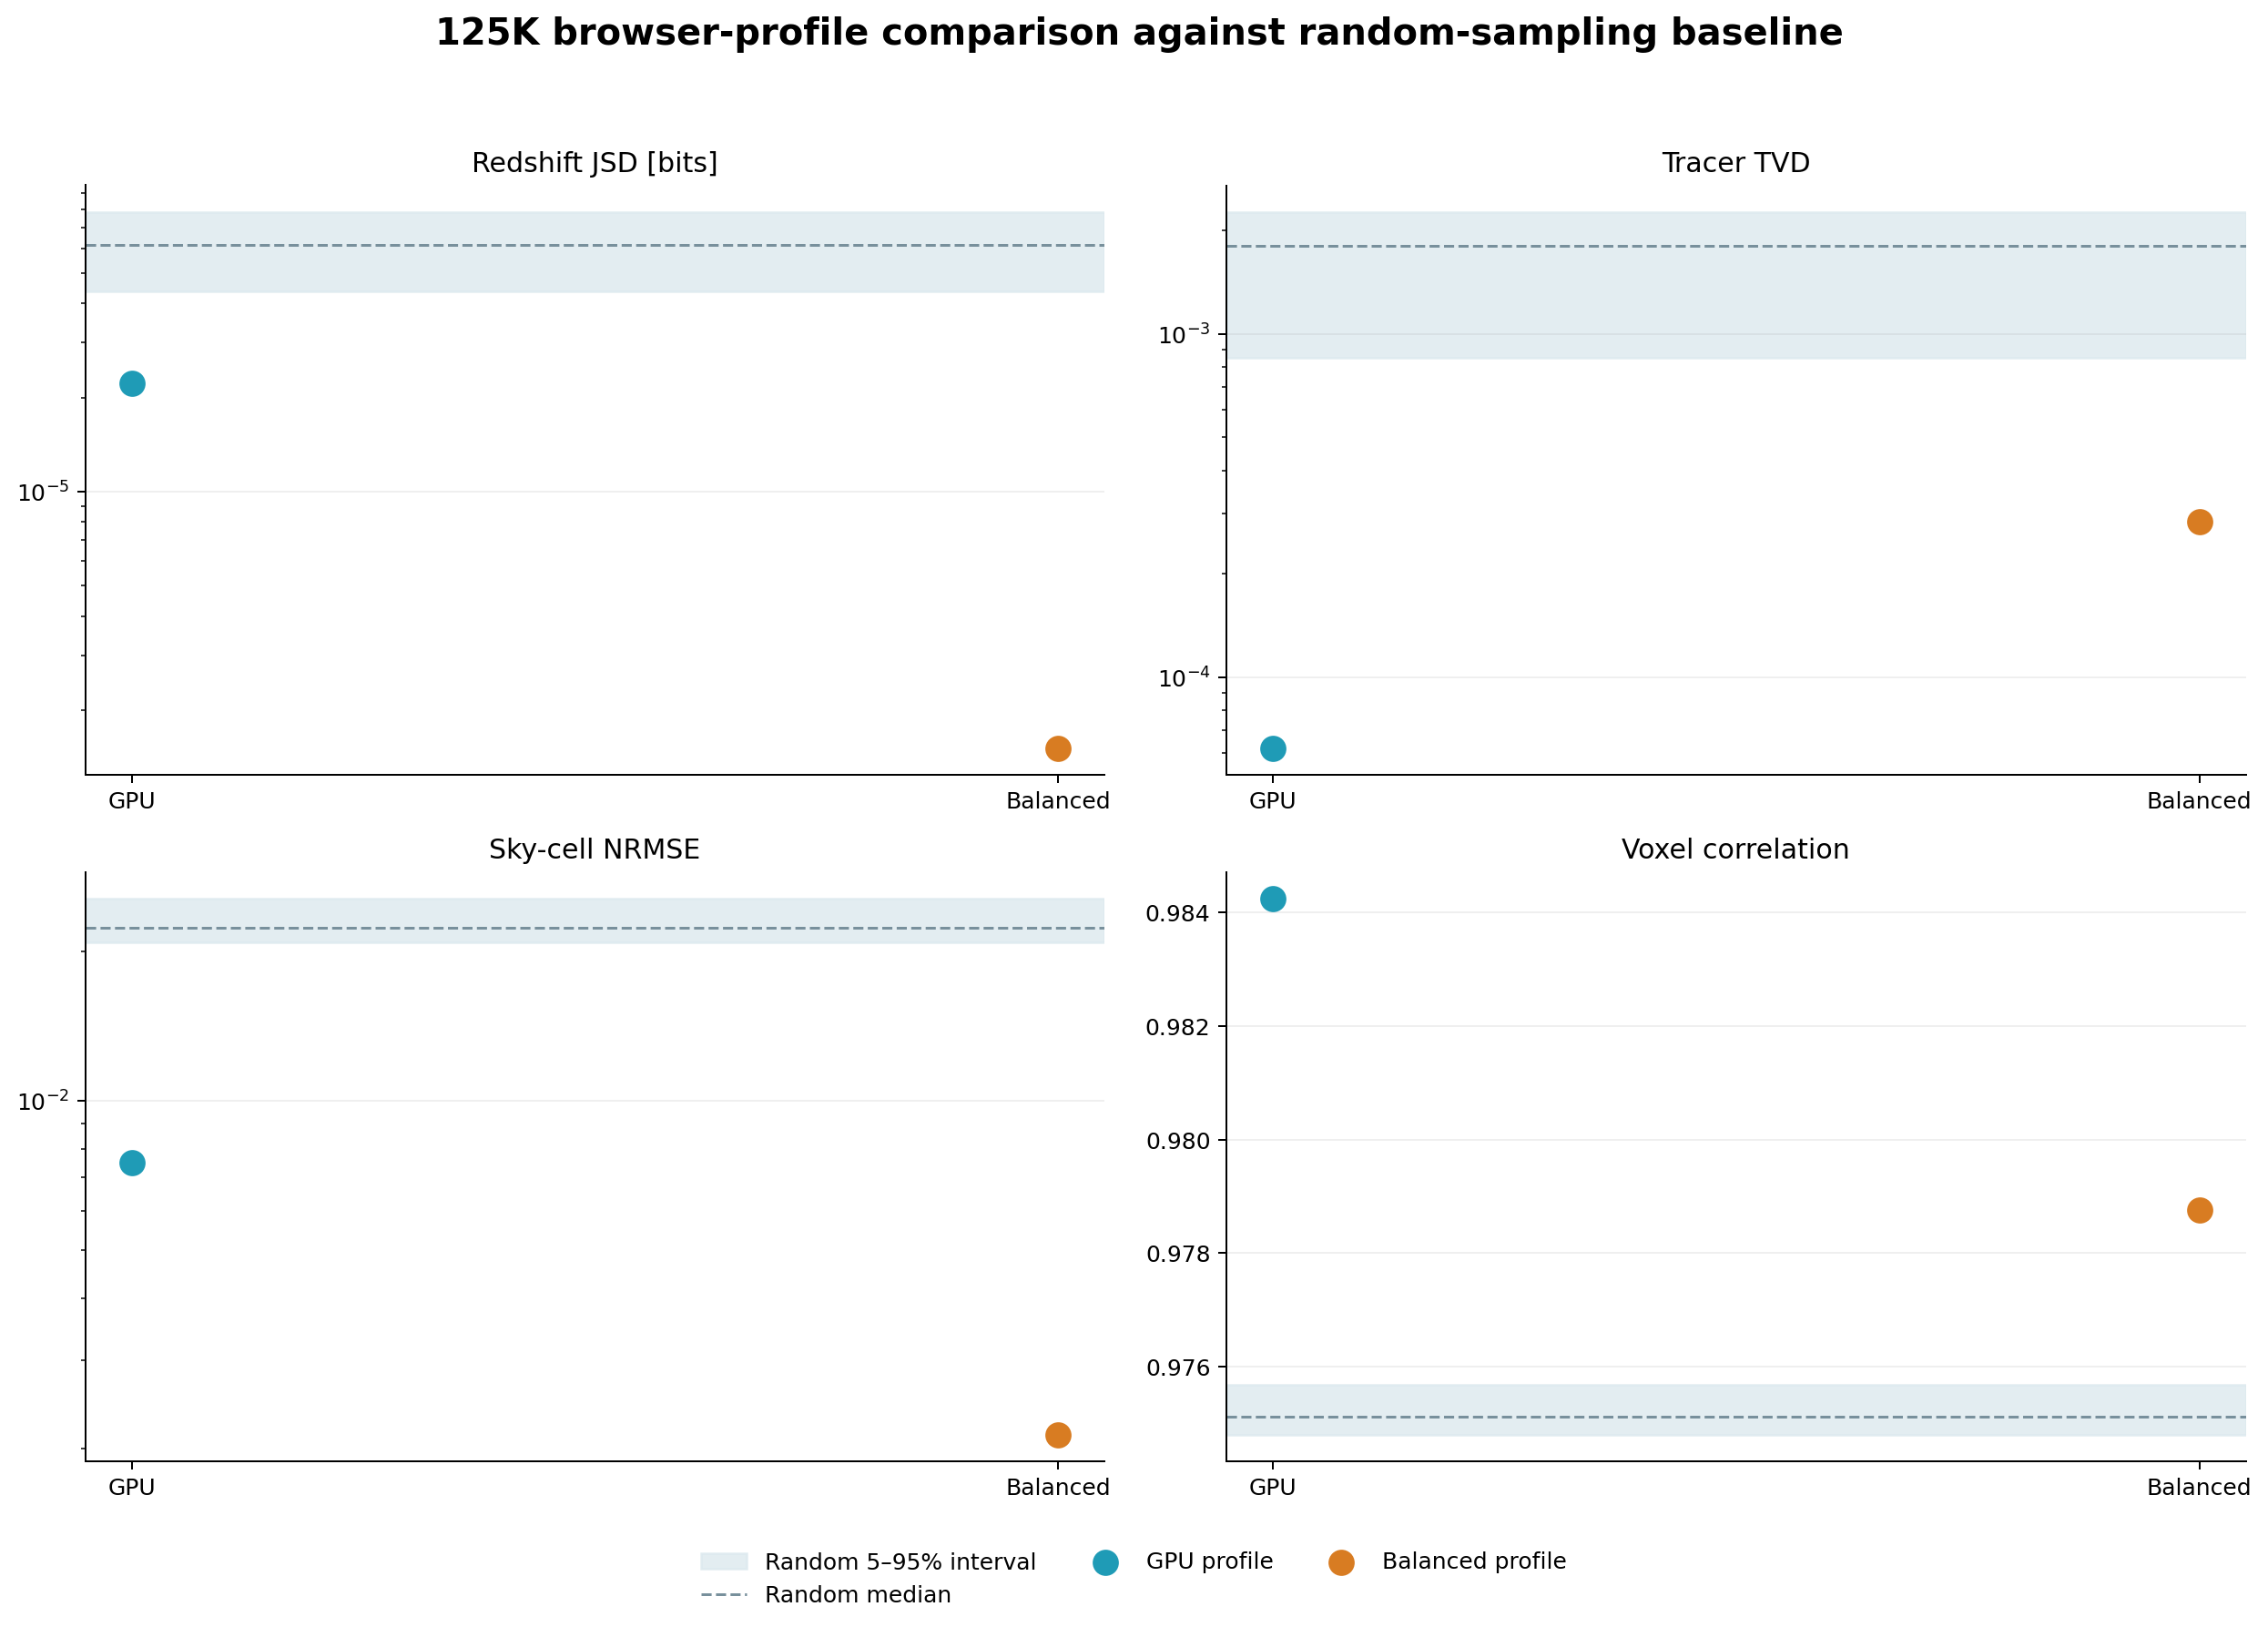

In [8]:
comparison = policy_metrics.copy()

gpu_row = comparison.loc[
    comparison["policy"] == "GPU low-discrepancy"
].iloc[0]

balanced_row = comparison.loc[
    comparison["policy"] == "Tracer-sky-redshift balanced"
].iloc[0]

random_rows = comparison.loc[
    comparison["policy"].str.startswith("Random baseline")
]

metric_specs = [
    ("redshift_js_bits", "Redshift JSD [bits]", True),
    ("tracer_tvd", "Tracer TVD", True),
    ("sky_nrmse", "Sky-cell NRMSE", True),
    ("voxel_correlation", "Voxel correlation", False),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=180)
fig.suptitle(
    "125K browser-profile comparison against random-sampling baseline",
    fontsize=16,
    fontweight="bold",
)

for axis, (metric, title, log_scale) in zip(axes.flat, metric_specs):
    random_values = random_rows[metric].to_numpy()

    axis.axhspan(
        np.quantile(random_values, 0.05),
        np.quantile(random_values, 0.95),
        color="#dce9ee",
        alpha=0.8,
        label="Random 5–95% interval",
    )

    axis.axhline(
        np.median(random_values),
        color="#78909c",
        linestyle="--",
        linewidth=1.2,
        label="Random median",
    )

    axis.scatter(
        [0],
        [gpu_row[metric]],
        s=110,
        color="#1f9bb6",
        label="GPU profile",
        zorder=4,
    )

    axis.scatter(
        [1],
        [balanced_row[metric]],
        s=110,
        color="#d87c22",
        label="Balanced profile",
        zorder=4,
    )

    axis.set_xticks([0, 1])
    axis.set_xticklabels(["GPU", "Balanced"])
    axis.set_title(title)

    if log_scale:
        axis.set_yscale("log")

    axis.grid(axis="y", alpha=0.2)
    axis.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 0.95))

fig.savefig(audit_dir / "03_policy_vs_random_baseline.png", dpi=300)
fig.savefig(audit_dir / "03_policy_vs_random_baseline.pdf")
plt.show()

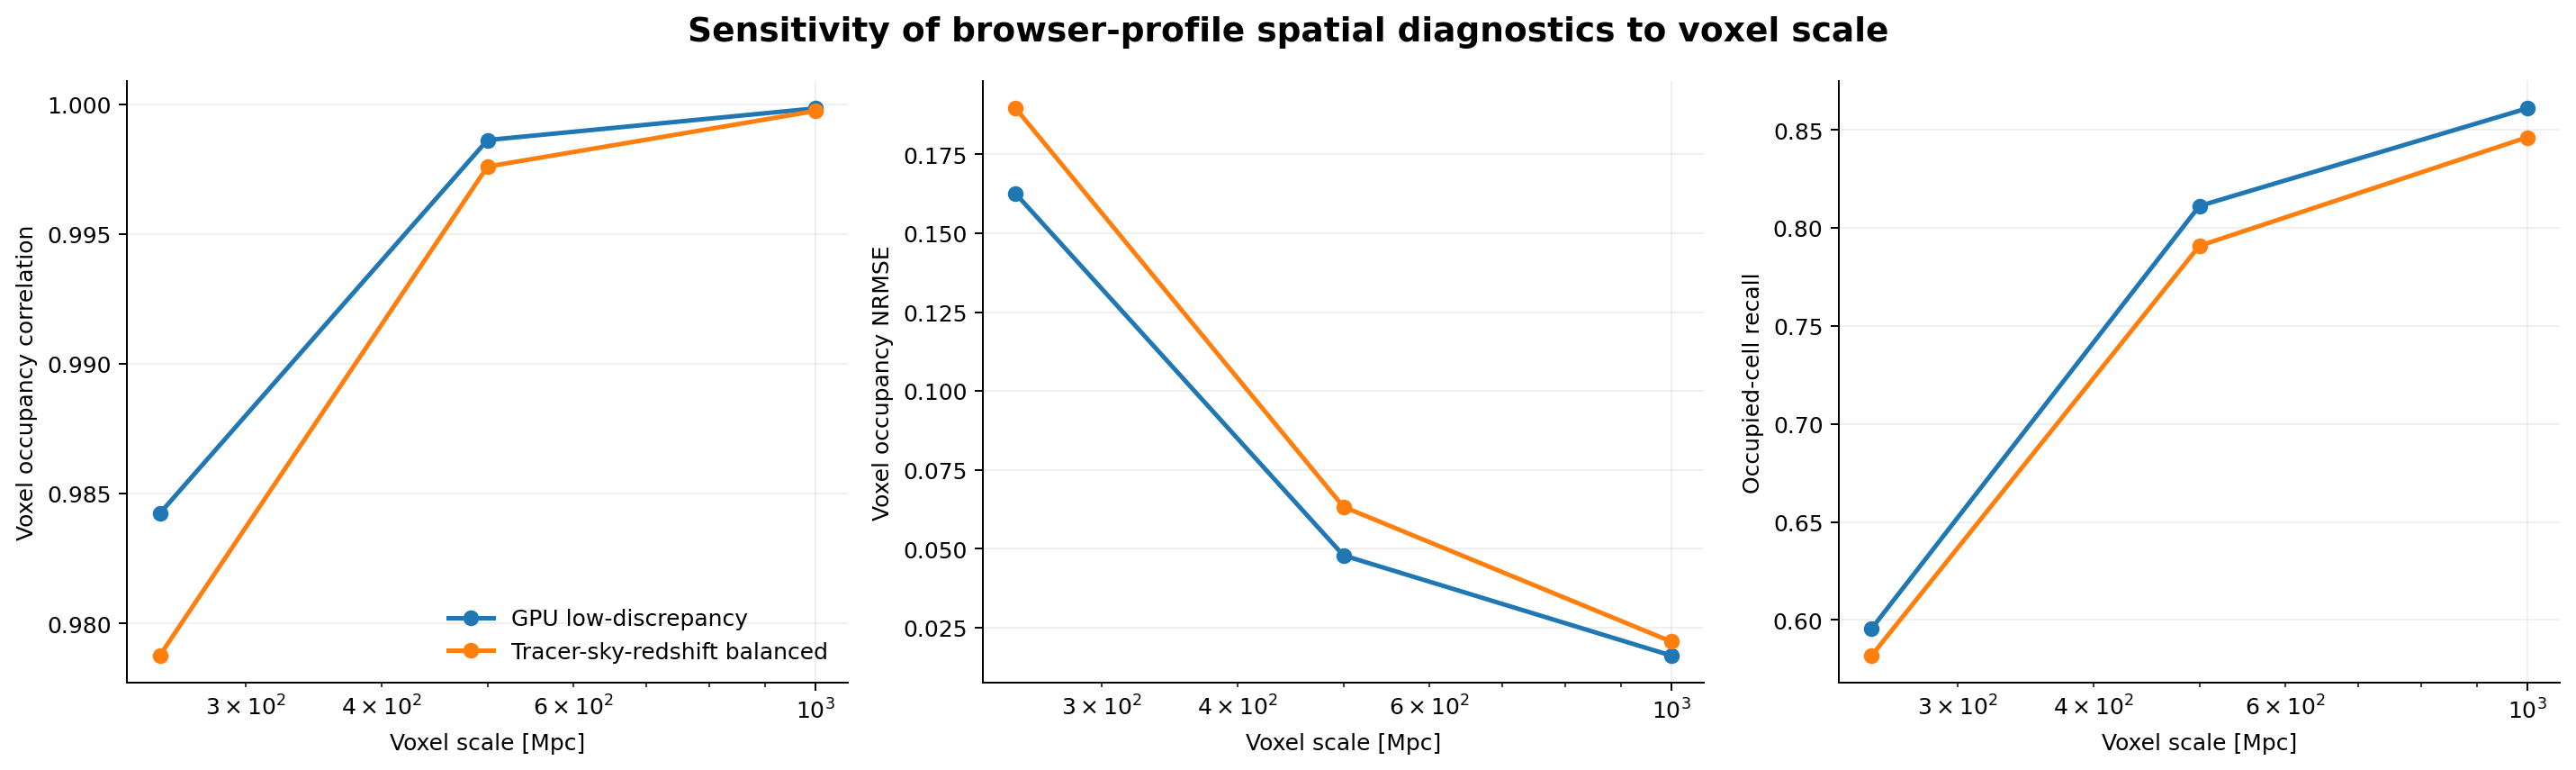

,policy,selected_rows,sampling_fraction,voxel_size_mpc,redshift_ks,redshift_js_bits,tracer_tvd,sky_correlation,sky_nrmse,sky_recall,voxel_correlation,voxel_nrmse,voxel_recall
0,GPU low-discrepancy,125001,0.020513,250.0,0.001185,0.000022,0.000062,0.999946,0.007505,0.977444,0.984242,0.162496,0.595644
1,Tracer-sky-redshift balanced,125000,0.020513,250.0,0.001393,0.000002,0.000284,0.999996,0.002130,0.954887,0.978769,0.189532,0.581878
2,GPU low-discrepancy,125001,0.020513,500.0,0.001185,0.000022,0.000062,0.999946,0.007505,0.977444,0.998621,0.047919,0.811216
3,Tracer-sky-redshift balanced,125000,0.020513,500.0,0.001393,0.000002,0.000284,0.999996,0.002130,0.954887,0.997599,0.063311,0.790882
4,GPU low-discrepancy,125001,0.020513,1000.0,0.001185,0.000022,0.000062,0.999946,0.007505,0.977444,0.999840,0.016168,0.861009
5,Tracer-sky-redshift balanced,125000,0.020513,1000.0,0.001393,0.000002,0.000284,0.999996,0.002130,0.954887,0.999740,0.020616,0.846248


In [9]:
scale_rows = []

for voxel_size in VOXEL_SCALES_MPC:
    scale_rows.append(
        evaluate_representation(
            gpu_sample,
            "GPU low-discrepancy",
            voxel_size_mpc=voxel_size,
        )
    )

    scale_rows.append(
        evaluate_representation(
            balanced_sample,
            "Tracer-sky-redshift balanced",
            voxel_size_mpc=voxel_size,
        )
    )

scale_metrics = pd.DataFrame(scale_rows)
scale_metrics.to_csv(
    audit_dir / "04_voxel_scale_sensitivity_metrics.csv",
    index=False,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), dpi=180)

for axis, metric, ylabel in zip(
    axes,
    ["voxel_correlation", "voxel_nrmse", "voxel_recall"],
    [
        "Voxel occupancy correlation",
        "Voxel occupancy NRMSE",
        "Occupied-cell recall",
    ],
):
    for policy, group in scale_metrics.groupby("policy"):
        axis.plot(
            group["voxel_size_mpc"],
            group[metric],
            marker="o",
            linewidth=2,
            label=policy,
        )

    axis.set_xscale("log")
    axis.set_xlabel("Voxel scale [Mpc]")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.2)
    axis.spines[["top", "right"]].set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle(
    "Sensitivity of browser-profile spatial diagnostics to voxel scale",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()
fig.savefig(audit_dir / "04_voxel_scale_sensitivity.png", dpi=300)
fig.savefig(audit_dir / "04_voxel_scale_sensitivity.pdf")
plt.show()

display(scale_metrics.round(7))

In [10]:
report = f"""
# NĀSADĪYA LIGHTCONE — Deep catalogue and representation audit

## Dataset
- Valid observed DESI DR1 LSS rows: {len(parent):,}
- Input SHA-256: {quality_summary["sha256"]}
- Duplicate object IDs after validation: {quality_summary["duplicate_object_ids"]}
- Redshift range: {parent["redshift"].min():.6f} to {parent["redshift"].max():.6f}
- Cartesian radial extent: {parent["radius_mpc"].max():.2f} Mpc

## 125K policy comparison
- GPU redshift JSD: {gpu_row["redshift_js_bits"]:.4e} bits
- Balanced redshift JSD: {balanced_row["redshift_js_bits"]:.4e} bits
- GPU sky NRMSE: {gpu_row["sky_nrmse"]:.6f}
- Balanced sky NRMSE: {balanced_row["sky_nrmse"]:.6f}
- GPU voxel correlation: {gpu_row["voxel_correlation"]:.6f}
- Balanced voxel correlation: {balanced_row["voxel_correlation"]:.6f}
- GPU voxel recall: {gpu_row["voxel_recall"]:.6f}
- Balanced voxel recall: {balanced_row["voxel_recall"]:.6f}

## Interpretation boundary
These results test browser representation of the same observed parent catalogue.
They are not survey-selection corrections, cosmological clustering measurements,
density reconstructions, void catalogues, or all-sky inferences.
"""

(audit_dir / "journal_audit_report.md").write_text(
    report.strip(),
    encoding="utf-8",
)

print(report)


# NĀSADĪYA LIGHTCONE — Deep catalogue and representation audit

## Dataset
- Valid observed DESI DR1 LSS rows: 6,093,818
- Input SHA-256: aba7c9236e516459e914d079e4b38bf1e75823ef0707e90da066914a5bda942e
- Duplicate object IDs after validation: 0
- Redshift range: 0.100034 to 3.499998
- Cartesian radial extent: 6951.62 Mpc

## 125K policy comparison
- GPU redshift JSD: 2.2152e-05 bits
- Balanced redshift JSD: 1.5141e-06 bits
- GPU sky NRMSE: 0.007505
- Balanced sky NRMSE: 0.002130
- GPU voxel correlation: 0.984242
- Balanced voxel correlation: 0.978769
- GPU voxel recall: 0.595644
- Balanced voxel recall: 0.581878

## Interpretation boundary
These results test browser representation of the same observed parent catalogue.
They are not survey-selection corrections, cosmological clustering measurements,
density reconstructions, void catalogues, or all-sky inferences.



In [11]:
import shutil
from google.colab import files

archive = shutil.make_archive(
    "/content/nasadiya_deep_analysis",
    "zip",
    audit_dir,
)

files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>